# Training Scan Pixel Intensity Analysis (Full)

Compute pixel intensity distribution and basic statistics for `inputs/train/**/scans/*.png`:
- Global: min/max/mean/std + quantiles (estimated from histogram)
- Per `case_day`: min/max/mean/std
- Per image: min/max/mean/std (one row per slice)

Notes:
- This notebook performs a **full scan** (about ~38k slices). Runtime depends on disk/CPU.
- Images are read with `cv2.IMREAD_UNCHANGED` to preserve original bit-depth (commonly `uint16`).


In [1]:
from __future__ import annotations

import json
import math
import os
import random
import re
import sys
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cv2
except Exception as e:
    raise RuntimeError("OpenCV (cv2) is required for this notebook.") from e


def find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "inputs" / "train.csv").exists():
            return p
        if (p / ".git").exists() and (p / "README.md").exists():
            return p
    raise RuntimeError(
        "Cannot find repo root. Start Jupyter from the project directory, or ensure inputs/train.csv exists."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("repo_root:", REPO_ROOT)

# -------- Config --------
TRAIN_DIR = Path("inputs/train")
OUT_DIR = Path("outputs/analysis")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Full scan (for sampling: set FULL_SCAN=False and set SAMPLE_N)
FULL_SCAN = True
SAMPLE_N: int | None = None if FULL_SCAN else 2000
SEED = 42

# If dtype is not uint8/uint16, approximate distribution with binned histogram (default 4096 bins)
BINS_FALLBACK = 4096

assert TRAIN_DIR.exists(), f"Not found: {TRAIN_DIR.resolve()}"
print("train_dir:", TRAIN_DIR)
print("full_scan:", FULL_SCAN)
print("sample_n:", SAMPLE_N)
print("out_dir:", OUT_DIR)

repo_root: /home/ubuntu/UW-Madison_GI_Tract_Image_Segmentation
train_dir: inputs/train
full_scan: True
sample_n: None
out_dir: outputs/analysis


## Enumerate scan PNGs

By default this runs on the full dataset. If `SAMPLE_N` is set, we use reservoir sampling (no need to store all paths ahead of time).


In [2]:
def iter_scan_pngs(train_dir: Path):
    # Expected layout: inputs/train/case*/case*_day*/scans/*.png
    for case_dir in sorted(train_dir.iterdir()):
        if not case_dir.is_dir():
            continue
        for day_dir in sorted(case_dir.iterdir()):
            scans_dir = day_dir / "scans"
            if not scans_dir.is_dir():
                continue
            for p in scans_dir.iterdir():
                if p.is_file() and p.suffix.lower() == ".png":
                    yield p


def reservoir_sample(paths_iter, n: int, seed: int = 42):
    rng = random.Random(seed)
    sample = []
    total = 0
    for p in paths_iter:
        total += 1
        if len(sample) < n:
            sample.append(p)
        else:
            j = rng.randrange(total)
            if j < n:
                sample[j] = p
    return sample, total


all_iter = iter_scan_pngs(TRAIN_DIR)
if SAMPLE_N is None:
    scan_paths = list(all_iter)
    total_pngs = len(scan_paths)
else:
    scan_paths, total_pngs = reservoir_sample(all_iter, SAMPLE_N, seed=SEED)

print("total pngs discovered:", f"{total_pngs:,}")
print("selected for analysis:", f"{len(scan_paths):,}")
scan_paths[:3]

total pngs discovered: 38,496
selected for analysis: 38,496


[PosixPath('inputs/train/case101/case101_day20/scans/slice_0038_266_266_1.50_1.50.png'),
 PosixPath('inputs/train/case101/case101_day20/scans/slice_0129_266_266_1.50_1.50.png'),
 PosixPath('inputs/train/case101/case101_day20/scans/slice_0103_266_266_1.50_1.50.png')]

## Helper functions


In [3]:
_CASE_DAY_RE = re.compile(r"^case\d+_day\d+$")


def case_day_from_path(p: Path) -> str:
    # inputs/train/caseXXX/caseXXX_dayY/scans/...
    parts = p.parts
    if len(parts) >= 3:
        candidate = parts[-3]
        if _CASE_DAY_RE.match(candidate):
            return candidate
    return "unknown"


@dataclass
class RunningStats:
    count: int = 0
    sum: float = 0.0
    sumsq: float = 0.0
    min: float = float("inf")
    max: float = float("-inf")

    def update(self, n: int, s: float, ss: float, vmin: float, vmax: float) -> None:
        if n <= 0:
            return
        self.count += int(n)
        self.sum += float(s)
        self.sumsq += float(ss)
        self.min = min(self.min, float(vmin))
        self.max = max(self.max, float(vmax))

    @property
    def mean(self) -> float:
        return (self.sum / self.count) if self.count else 0.0

    @property
    def std(self) -> float:
        if not self.count:
            return 0.0
        var = (self.sumsq / self.count) - (self.mean ** 2)
        return float(math.sqrt(max(var, 0.0)))


def percentile_from_hist(edges: np.ndarray, hist: np.ndarray, q: float) -> float:
    # q in [0,1]
    total = float(hist.sum())
    if total <= 0:
        return 0.0
    target = q * total
    cdf = np.cumsum(hist, dtype=np.float64)
    idx = int(np.searchsorted(cdf, target, side="left"))
    idx = min(max(idx, 0), len(hist) - 1)
    lo = float(edges[idx])
    hi = float(edges[idx + 1])
    prev = float(cdf[idx - 1]) if idx > 0 else 0.0
    within = (target - prev) / max(float(hist[idx]), 1.0)
    return lo + within * (hi - lo)


## Scan and accumulate statistics


In [4]:
if not scan_paths:
    raise RuntimeError("No scan png found under inputs/train")

first = cv2.imread(str(scan_paths[0]), cv2.IMREAD_UNCHANGED)
if first is None:
    raise RuntimeError(f"Failed to read image: {scan_paths[0]}")
if first.ndim == 3:
    first = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY)

dtype = first.dtype
print("dtype:", dtype)
print("shape example:", first.shape)
print("min/max example:", float(first.min()), float(first.max()))

# Set up histogram bins
if dtype == np.uint8:
    nbins = 256
    hist_edges = np.arange(nbins + 1, dtype=np.float64)
    exact_hist = True
elif dtype == np.uint16:
    nbins = 65536
    hist_edges = np.arange(nbins + 1, dtype=np.float64)
    exact_hist = True
else:
    # Fallback: approximate histogram across observed range of the first image.
    nbins = int(BINS_FALLBACK)
    vmin = float(first.min())
    vmax = float(first.max())
    hist_edges = np.linspace(vmin, vmax + 1e-6, num=nbins + 1, dtype=np.float64)
    exact_hist = False

x = (hist_edges[:-1] + hist_edges[1:]) / 2.0
x2 = x ** 2
global_hist = np.zeros(nbins, dtype=np.int64)
global_stats = RunningStats()
case_day_stats: dict[str, RunningStats] = defaultdict(RunningStats)

per_image_records = []

for i, p in enumerate(scan_paths, start=1):
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    if img is None:
        continue
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    if exact_hist:
        # uint8/uint16 exact intensity histogram
        h = np.bincount(img.reshape(-1), minlength=nbins).astype(np.int64)
    else:
        h, _ = np.histogram(img.reshape(-1), bins=hist_edges)
        h = h.astype(np.int64)

    n = int(h.sum())
    s = float(np.dot(h.astype(np.float64, copy=False), x))
    ss = float(np.dot(h.astype(np.float64, copy=False), x2))

    nz = np.flatnonzero(h)
    vmin = float(x[nz[0]]) if nz.size else 0.0
    vmax = float(x[nz[-1]]) if nz.size else 0.0

    global_hist += h
    global_stats.update(n=n, s=s, ss=ss, vmin=vmin, vmax=vmax)

    cd = case_day_from_path(p)
    case_day_stats[cd].update(n=n, s=s, ss=ss, vmin=vmin, vmax=vmax)

    mean = (s / n) if n else 0.0
    var = (ss / n - mean ** 2) if n else 0.0
    std = float(math.sqrt(max(var, 0.0)))

    per_image_records.append(
        {
            "path": str(p),
            "case_day": cd,
            "dtype": str(img.dtype),
            "height": int(img.shape[0]),
            "width": int(img.shape[1]),
            "min": vmin,
            "max": vmax,
            "mean": float(mean),
            "std": float(std),
        }
    )

    if i % 500 == 0:
        print(f"processed {i:,}/{len(scan_paths):,} images...")

per_image_df = pd.DataFrame.from_records(per_image_records)
print("processed images:", len(per_image_df))
per_image_df.head()

dtype: uint16
shape example: (266, 266)
min/max example: 0.0 407.0
processed 500/38,496 images...
processed 1,000/38,496 images...
processed 1,500/38,496 images...
processed 2,000/38,496 images...
processed 2,500/38,496 images...
processed 3,000/38,496 images...
processed 3,500/38,496 images...
processed 4,000/38,496 images...
processed 4,500/38,496 images...
processed 5,000/38,496 images...
processed 5,500/38,496 images...
processed 6,000/38,496 images...
processed 6,500/38,496 images...
processed 7,000/38,496 images...
processed 7,500/38,496 images...
processed 8,000/38,496 images...
processed 8,500/38,496 images...
processed 9,000/38,496 images...
processed 9,500/38,496 images...
processed 10,000/38,496 images...
processed 10,500/38,496 images...
processed 11,000/38,496 images...
processed 11,500/38,496 images...
processed 12,000/38,496 images...
processed 12,500/38,496 images...
processed 13,000/38,496 images...
processed 13,500/38,496 images...
processed 14,000/38,496 images...
pr

,path,case_day,dtype,height,width,min,max,mean,std
0,inputs/train/case101/case101_day20/scans/slice...,case101_day20,uint16,266,266,0.5,407.5,41.610068,63.886349
1,inputs/train/case101/case101_day20/scans/slice...,case101_day20,uint16,266,266,0.5,607.5,36.517073,48.359583
2,inputs/train/case101/case101_day20/scans/slice...,case101_day20,uint16,266,266,0.5,544.5,90.140850,104.987987
3,inputs/train/case101/case101_day20/scans/slice...,case101_day20,uint16,266,266,0.5,163.5,16.739824,21.653092
4,inputs/train/case101/case101_day20/scans/slice...,case101_day20,uint16,266,266,0.5,420.5,71.132144,82.841861


## Global summary statistics


In [5]:
quantiles = [0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999]
global_percentiles = {f"p{int(q*1000):03d}": percentile_from_hist(hist_edges, global_hist, q) for q in quantiles}

global_summary = {
    "train_dir": str(TRAIN_DIR.resolve()),
    "full_scan": bool(FULL_SCAN),
    "sample_n": SAMPLE_N,
    "total_pngs_discovered": int(total_pngs),
    "images_processed": int(len(per_image_df)),
    "dtype": str(dtype),
    "global": {
        "pixel_count": int(global_stats.count),
        "min": float(global_stats.min if global_stats.count else 0.0),
        "max": float(global_stats.max if global_stats.count else 0.0),
        "mean": float(global_stats.mean),
        "std": float(global_stats.std),
        **global_percentiles,
    },
}

pd.Series(global_summary["global"])

pixel_count    3.186783e+09
min            5.000000e-01
max            1.586550e+04
mean           6.683625e+02
std            1.540793e+03
p001           5.162838e-03
p010           5.162838e-02
p050           2.581419e-01
p500           5.747895e+01
p950           4.278407e+03
p990           7.452373e+03
p999           9.954913e+03
dtype: float64

## Global histogram


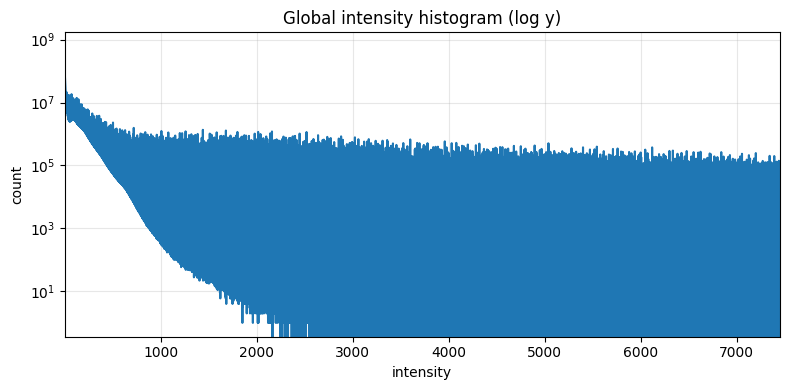

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x, global_hist.astype(np.float64))
ax.set_title("Global intensity histogram (log y)")
ax.set_xlabel("intensity")
ax.set_ylabel("count")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

# tighten xlim for readability
lo = global_percentiles.get("p010", None)
hi = global_percentiles.get("p990", None)
if lo is not None and hi is not None and hi > lo:
    ax.set_xlim(lo, hi)

plt.tight_layout()
plt.show()

## Per-image distribution (mean/std)


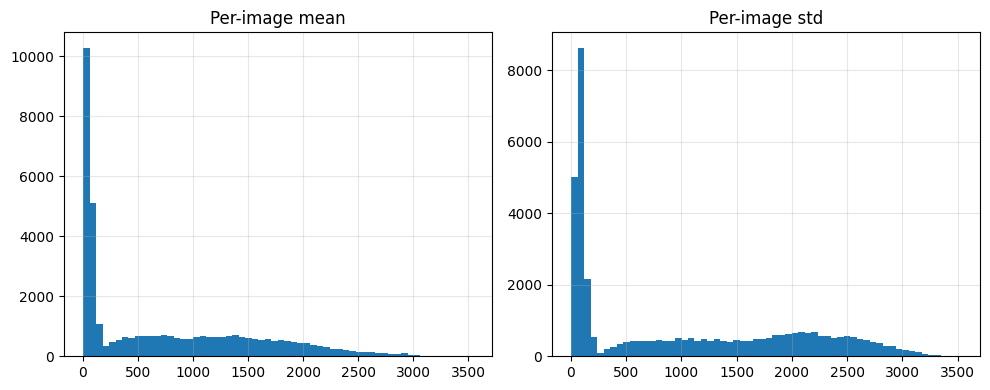

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(per_image_df["mean"], bins=60)
axes[0].set_title("Per-image mean")
axes[0].grid(True, alpha=0.3)

axes[1].hist(per_image_df["std"], bins=60)
axes[1].set_title("Per-image std")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Per-`case_day` summary (pixel mean/variance)


In [8]:
case_day_rows = []
for cd, st in case_day_stats.items():
    case_day_rows.append(
        {
            "case_day": cd,
            "pixel_count": int(st.count),
            "min": float(st.min if st.count else 0.0),
            "max": float(st.max if st.count else 0.0),
            "mean": float(st.mean),
            "std": float(st.std),
        }
    )

case_day_df = pd.DataFrame.from_records(case_day_rows)
case_day_df = case_day_df.sort_values(["pixel_count", "mean"], ascending=False)
case_day_df.head(20)

,case_day,pixel_count,min,max,mean,std
36,case119_day0,16070400,0.5,15314.5,1342.592973,2176.374892
44,case122_day0,16070400,0.5,15650.5,1173.920293,2023.097205
197,case47_day29,16070400,0.5,15789.5,738.465427,1331.242060
260,case88_day38,16070400,0.5,15225.5,718.066865,1102.802076
200,case49_day15,16070400,0.5,15255.5,600.119523,1011.052220
259,case88_day36,16070400,0.5,15840.5,568.885419,892.546425
196,case47_day27,16070400,0.5,15360.5,559.989230,994.935931
258,case88_day0,16070400,0.5,15008.5,537.071443,826.264171
75,case134_day21,16070400,0.5,15120.5,518.056902,849.684133
81,case136_day27,16070400,0.5,15751.5,479.366082,971.743445


## Export results (CSV/JSON)


In [9]:
out_case_day_csv = OUT_DIR / "intensity_by_case_day.csv"
out_image_csv = OUT_DIR / "intensity_by_image.csv"
out_summary_json = OUT_DIR / "intensity_summary.json"

case_day_df.to_csv(out_case_day_csv, index=False)
per_image_df.to_csv(out_image_csv, index=False)
with open(out_summary_json, "w", encoding="utf-8") as f:
    json.dump(global_summary, f, indent=2, ensure_ascii=False)

print("wrote:", out_case_day_csv)
print("wrote:", out_image_csv)
print("wrote:", out_summary_json)

wrote: outputs/analysis/intensity_by_case_day.csv
wrote: outputs/analysis/intensity_by_image.csv
wrote: outputs/analysis/intensity_summary.json
